# Overlevelsesanalyse af tid til frafald i en studenterkohorte

## Resumé

**Kontekst.** Et kontor for institutionsanalyse på et fireårigt college ønsker at forstå *hvornår*, ikke bare *hvorvidt*, studerende forlader studiet. En førstegangskohorte følges semester for semester fra indskrivningen; nogle dimitterer, nogle falder fra, og enkelte er stadig indskrevet, når observationsvinduet lukker. Fordi udfaldet for stadig indskrevne studerende er ukendt (højrecensureret), og fordi dimission fjerner en studerende fra risikopuljen uden at være et frafald, kasserer almindelig bestå/dumpe-regression timing-informationen og skaber bias i ethvert estimat, der ignorerer censurering. Det rette værktøj er **tid-til-hændelse-analyse (overlevelsesanalyse)**, hvor den interessante hændelse er **frafald**, og uret måles i indskrevne akademiske semestre.

**Forretningsspørgsmål.** Adskiller en studerendes **akademiske status i første semester** (et tidligt varselsflag) kohortens frafaldstiming-forløb, og hvilke studenterkarakteristika driver frafaldsrisikoen efter justering? Svarene indgår i et tidligt varslingssystem: studerende, hvis estimerede frafaldsrisiko er høj, bør modtage vejledningsopsøgning i deres første semestre, hvor indsatsen er billigst og mest effektiv.

**Fremgangsmåde.** Vi simulerer en kohorte på 100 studerende inline (ingen eksterne data) og arbejder derefter gennem et standard overlevelses-workflow:

1. **PROC MEANS** profilerer prædiktorerne på tværs af de tre observerede udfald (dimitteret / frafaldet / stadig indskrevet) for at bekræfte, at det simulerede signal opfører sig fornuftigt.
2. **PROC FREQ** krydstabulerer akademisk status i første semester mod udfald med en chi-i-anden-test for association.
3. **PROC UNIVARIATE** rapporterer robuste percentiler for tid til frafald efter status.
4. **PROC LIFETEST** estimerer Kaplan-Meier-frafaldskurver stratificeret efter status og kører **log-rank**- og **Wilcoxon**-tests for lighed.
5. **PROC PHREG** tilpasser en multivariabel **Cox proportional-hazard**-model for frafaldsrisikoen med en referencekodet `CLASS`-effekt, Efron-håndtering af sammenfald og risikogrænse-konfidensintervaller.

**Hvad data viser.** Af de 100 simulerede studerende **faldt 49 fra, 49 dimitterede, og 2 forblev indskrevet** ved 12-semester-grænsen. Studerende, der blev markeret med **akademisk advarsel** i deres første semester (første-semester-GPA under 2.5), falder fra langt hurtigere end studerende med god status: median tid til frafald **3.8 semestre mod 8.7 semestre**, en adskillelse som log-rank-testen bekræfter (chi-i-anden = 10.73, *p* = 0.0011). Cox-modellen identificerer første-semester-GPA (hazard ratio 0.21 pr. GPA-point, *p* < 0.0001), high school-GPA (HR 0.45, *p* = 0.027) og status som første generation (HR 2.03, *p* = 0.031) som signifikante justerede drivere af frafald, mens Pell-legat-status ikke er signifikant, når der kontrolleres for GPA (HR 0.95, *p* = 0.85).

> *Alle tal er illustrative og genereret ud fra syntetiske data; de er ikke rigtige studenterjournaler. Dette miljø kører uden licens, så kohorten er dimensioneret til 100 studerende.*

## Datakilder

Alle data er **syntetiske**, genereret inline i det første DATA step med `CALL STREAMINIT(20260611)` og `RAND`-funktionen. Ingen eksterne filer eller netværksadgang. Én række pr. simuleret studerende.

**Datasæt `indskrivninger`** (100 rækker, én række pr. studerende)

| Variabel | Type | Beskrivelse | Genererende fordeling |
|----------|------|-------------|--------------------------|
| `studerende_id` | Num | Unik studenternøgle | sekvens 1–100 |
| `foerste_gen` / `foerste_gen_tekst` | Num / Char | Flag for første generation (0/1) og etiket | Bernoulli, ~42% |
| `pell` | Num | Pell-legat-flag (økonomisk behov) (0/1) | Bernoulli, ~42% |
| `program` | Char | STEM / BUS / HUM | kategorisk (~42% / 32% / 26%) |
| `gym_snit` | Num | High school-GPA (1.8–4.0) | Normal(3.00, 0.42), afgrænset |
| `sem1_snit` | Num | GPA i første college-semester (0–4.0) | f(gym_snit, program) + Normal-støj |
| `status` | Char | Akademisk status i første semester | `sem1_snit < 2.5` → akademisk advarsel, ellers god status |
| `tid_semestre` | Num | Semestre indskrevet indtil hændelse eller censurering | konkurrerende Weibull-udtræk; loft ved 12 |
| `dropped` | Num | Frafaldshændelses-indikator (1 = frafaldet, 0 = censureret) | afledt |
| `udfald` | Char | Dimitteret / frafaldet / indskrevet | afledt af konkurrerende udtræk |

En latent lineær prædiktor på log-skalaen forbinder hver studerendes **frafaldsrate** med første-semester-GPA, high school-GPA, status som første generation og økonomisk behov, så prædiktorerne bærer et ægte, men støjfyldt signal. Frafald og dimission udtrækkes som **konkurrerende** latente tider (Weibull); hvad end der sker først inden for et 12-semester-vindue, bliver det observerede udfald, og studerende, der når semester 12 uden nogen af delene, højrecensureres. For overlevelsesmodellerne er **hændelsen frafald** (`frafaldet = 1`); dimission og igangværende indskrivning behandles begge som censurering (`frafaldet = 0`).

## 1. Simulér studenterkohorten

Den første celle bygger en syntetisk kohorte på 100 studerende. En latent lineær prædiktor på log-skalaen knytter hver studerendes frafaldsrate til første-semester-GPA, high school-GPA, status som første generation og Pell-status. Frafald og dimission genereres som **konkurrerende** latente tider (Weibull-udtræk); hvad end der sker først inden for et 12-semester-observationsvindue, bliver det observerede udfald, og studerende, der når semester 12 uden at falde fra eller dimittere, højrecensureres. En første-semester-GPA under 2.5 markerer den studerende med **akademisk advarsel** — det tidlige varselssignal, vi tester i overlevelsestrinnet. Tilfældige udtræk bruger `CALL STREAMINIT` for reproducerbarhed og `RAND`-funktionen på tværs af Uniform-, Normal- og Weibull-fordelinger. Hårde gulve og afgrænsninger holder hver værdi plausibel (GPA'er i 0–4.0).

In [1]:
data indskrivninger;
    CALL streaminit(20260611);
    LÆNGDE status $24 foerste_gen_tekst $24 program $4 udfald $12;
    MÆRKAT studerende_id     = "Studenternøgle"
          foerste_gen       = "Første generation (0/1)"
          foerste_gen_tekst = "Status for generation"
          pell              = "Pell-legat (0/1)"
          program           = "Studieprogram"
          gym_snit          = "Gymnasie-GPA"
          sem1_snit         = "Første-semester-GPA"
          status            = "Akademisk status"
          tid_semestre      = "Semestre indskrevet"
          frafaldet         = "Frafaldshændelse (1=ja)"
          udfald            = "Udfald";
    GØR studerende_id = 1 TIL 100;
        /* Flag for første generation og økonomisk behov */
        foerste_gen = (rand("uniform") < 0.42);
        HVIS foerste_gen SÅ foerste_gen_tekst = "Første generation";
        ELLERS                foerste_gen_tekst = "Fortsættende generation";
        pell = (rand("uniform") < 0.42);

        /* Studieprogram */
        v = rand("uniform");
        HVIS      v < 0.42 SÅ program = "STEM";
        ELLERS HVIS v < 0.74 SÅ program = "BUS";
        ELLERS                  program = "HUM";

        /* Akademisk forberedelse og præstation i første semester */
        gym_snit = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        sem1_snit = round(MIN(4.0, MAX(0.0,
                     0.55*gym_snit + 1.05 + 0.12*(program="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Tidligt varselsflag: første-semester-GPA under 2.5 = akademisk advarsel */
        HVIS sem1_snit < 2.5 SÅ status = "Akademisk advarsel";
        ELLERS                    status = "God status";

        /* Latent frafaldsrisiko på log-skalaen: lavere GPA, første
           generation og Pell-status hæver frafaldsraten. */
        eta = -1.05
             - 1.45*(sem1_snit - 2.8)
             - 0.55*(gym_snit - 3.0)
             + 1.05*foerste_gen
             + 0.45*pell;
        frafaldsrate = EXP(eta);

        /* Konkurrerende latente tider (semestre): frafald vs. dimission */
        t_fra = rand("weibull", 1.2, 7.0) / MAX(0.30, frafaldsrate);
        t_dim = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(sem1_snit - 2.8));

        /* 12-semester administrativt censureringsvindue */
        censur_ved = 12;
        HVIS t_fra <= t_dim AND t_fra <= censur_ved SÅ GØR;
            udfald = "Frafaldet";   frafaldet = 1; tid_semestre = t_fra;
        SLUT;
        ELLERS HVIS t_dim < t_fra AND t_dim <= censur_ved SÅ GØR;
            udfald = "Dimitteret"; frafaldet = 0; tid_semestre = t_dim;
        SLUT;
        ELLERS GØR;
            udfald = "Indskrevet";  frafaldet = 0; tid_semestre = censur_ved;
        SLUT;
        tid_semestre = round(tid_semestre, 0.1);
        UDDATA;
    SLUT;
    BEHOLD studerende_id foerste_gen foerste_gen_tekst pell program gym_snit
         sem1_snit status tid_semestre frafaldet udfald;
KØR;


NOTE: DATA indskrivninger


NOTE: Wrote indskrivninger (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profilér prædiktorer efter observeret udfald

Før modellering bekræfter vi, at de simulerede prædiktorer bevæger sig i de forventede retninger. **PROC MEANS** rapporterer antal, gennemsnit, spredning og interval for hver numerisk prædiktor inden for de tre observerede udfald.

Kohorten fordeler sig **49 dimitteret / 49 frafaldet / 2 stadig indskrevet**. Dimittender bærer en højere første-semester-GPA (gennemsnit **2.94** mod **2.54** for studerende, der faldt fra) og en højere high school-GPA (**3.10** mod **2.90**) — præcis den akademiske forberedelsesgradient, som analysen forventer. De to stadig indskrevne studerende ligger nøjagtigt på 12-semester-censureringsloftet for `tid_semestre` (gennemsnit 12.00, standardafvigelse 0), den højrecensurering som en frafaldsanalyse skal respektere. Blandt studerende, der faldt fra, indtræffer hændelsen tidligt: gennemsnit **3.31 semestre**, spændende fra 0.1 til 8.9.

In [2]:
PROCEDURE GENNEMSNIT data=indskrivninger n mean std MIN MAX maxdec=2;
    KLASSE udfald;
    VARIABEL gym_snit sem1_snit tid_semestre;
KØR;

                                                  The MEANS Procedure

                                       Analysis Variable : gym_snit Gymnasie-GPA

        Udfald              N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Dimitteret             49           3.10           0.46           1.97           4.00
        Frafaldet              49           2.90           0.45           2.01           3.89
        Indskrevet              2           3.10           0.17           2.98           3.22
        -------------------------------------------------------------------------------------

                                   Analysis Variable : sem1_snit Første-semester-GPA

        Udfald              N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Følger det tidlige varselsflag udfaldet?

Det tidlige varslingssystem markerer enhver studerende, hvis første-semester-GPA falder under 2.5, med **akademisk advarsel**. **PROC FREQ** krydstabulerer det flag mod det observerede udfald og kører en chi-i-anden-test for association. Vi undertrykker række-, kolonne- og totalprocenter (`NOROW NOCOL NOPERCENT`), så tabellen viser de rå tællinger, og tilføjer envejsfrekvenser af `status` og status som første generation for kohortens sammensætning.

Krydstabellen er skarp: af de **29** studerende, der blev markeret med akademisk advarsel, **faldt 21 fra** og kun 8 dimitterede; af de **71** med god status **dimitterede 41** og 28 faldt fra. Associationen er signifikant (chi-i-anden = 9.21, df = 2, *p* = 0.0100; Cramérs V = 0.30). Bemærk **advarslen, der udskrives sammen med den**: med 100 studerende og en tynd "indskrevet"-kolonne med to dimittender har en tredjedel af tabelcellerne forventede tællinger under 5, så chi-i-anden-*p*-værdien er skrøbelig her. Netop den skrøbelighed er grunden til, at overlevelsestestene i de næste afsnit — som bruger den fulde timing-information i stedet for en 3×2-tabel — er den mere troværdige test af statuseffekten.

                                                   The FREQ Procedure

Table of Akademisk status by Udfald

Akademisk status   |Dimitteret | Frafaldet |Indskrevet |      Total
-------------------+-----------+-----------+-----------+-----------
Akademisk advarsel |         8 |        21 |         0 |         29
-------------------+-----------+-----------+-----------+-----------
God status         |        41 |        28 |         2 |         71
-------------------+-----------+-----------+-----------+-----------
Total              |        49 |        49 |         2 |        100

Statistics for Table of Akademisk status by Udfald

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.2904


                 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_status_udfald.spec.json
NOTE: ODS plot written: freq_status.spec.json
NOTE: ODS plot written: freq_foerste_gen_tekst.spec.json
NOTE: PROC FREQ statement used.


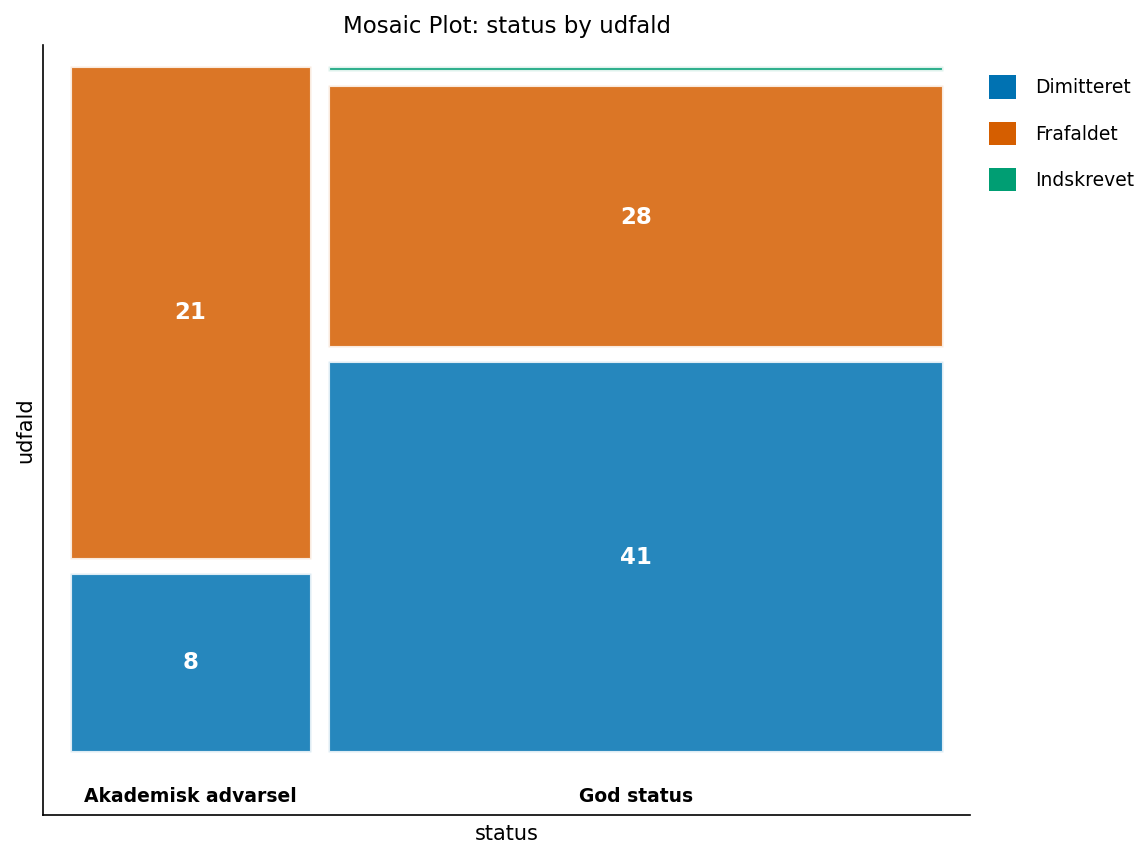

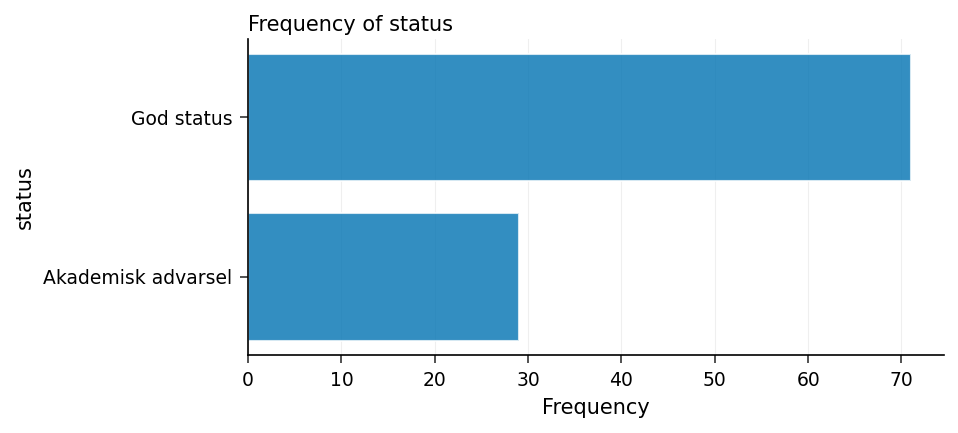

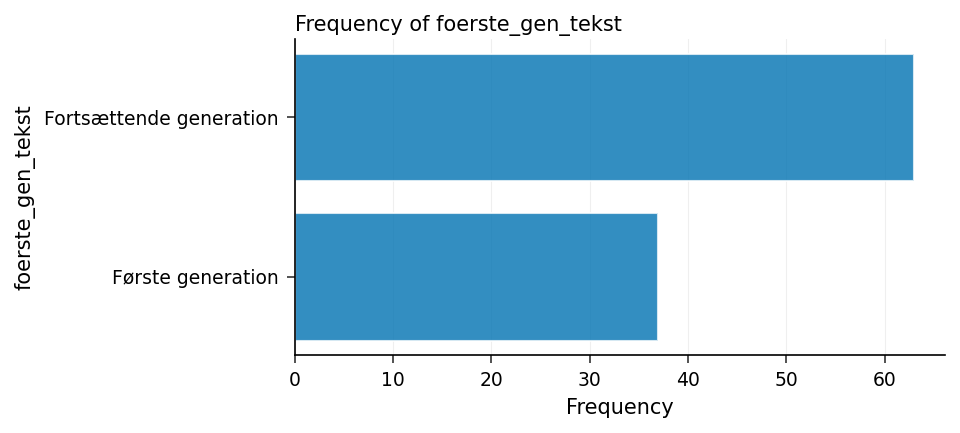

In [3]:
PROCEDURE FREKVENSER data=indskrivninger;
    TABLES status*udfald / chisq norow nocol nopercent;
    TABLES status foerste_gen_tekst;
KØR;

## 4. Hvornår sker frafald? Percentiler efter status

For de studerende, der faktisk faldt fra, *hvornår* forlod de studiet? **PROC UNIVARIATE** (begrænset til `frafaldet = 1`) rapporterer den 10., 50. (median) og 90. percentil for tid til frafald inden for hver statusgruppe, skrevet til et outputdatasæt, som vi derefter udskriver. Dette beskriver spredningen af frafaldstiming uden at antage en fordeling.

Median-frafaldet blandt studerende, der forlod studiet, indtræffer omkring semester **2.4** (akademisk advarsel) mod **2.6** (god status) — tæt på hinanden, fordi *betinget af frafald* har begge grupper tendens til at forlade studiet tidligt. Statuseffekten handler derfor ikke primært om *hvornår* et frafald sker, men om *hvor mange* studerende der falder fra, og hvor hurtigt risikopuljen tyndes ud, hvilket er præcis, hvad Kaplan-Meier-kurverne i næste afsnit indfanger.

In [4]:
PROCEDURE UNIVARIATE data=indskrivninger NOPRINT;
    HVOR frafaldet = 1;
    KLASSE status;
    VARIABEL tid_semestre;
    UDDATA out=frafald_ref pctlpts=10 50 90 pctlpre=t_ p=;
KØR;

PROCEDURE UDSKRIV data=frafald_ref noobs MÆRKAT;
    MÆRKAT status = "Akademisk status"
          t_10   = "10. percentil"
          t_50   = "Median"
          t_90   = "90. percentil";
    TITEL "Percentiler for tid til frafald (semestre), efter akademisk status";
KØR;
TITEL;

                           Percentiler for tid til frafald (semestre), efter akademisk status                           

  Akademisk status  10. percentil  Median  90. percentil
Akademisk advarsel            0.2     2.4            7.9
God status                    0.4     2.6            8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset frafald_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=frafald_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meier-frafaldskurver efter akademisk status

Nu det centrale overlevelsestrin. **PROC LIFETEST** estimerer den nonparametriske **Kaplan-Meier**-overlevelsesfunktion for *tid til frafald* og behandler dimission og igangværende indskrivning som censurering (`frafaldet(0)` markerer de censurerede observationer). Stratificering efter `status` producerer én frafaldskurve pr. gruppe, og `TEST=(LOGRANK WILCOXON)` kører to komplementære tests af, om kurverne adskiller sig: **log-rank**-testen vægter alle hændelsestidspunkter lige (følsom over for sene forskelle), mens **Wilcoxon**-testen opvægter tidlige hændelsestidspunkter (følsom over for tidligt frafald). `PLOTS=SURVIVAL` anmoder om den overlejrede overlevelseskurve-grafik.

På tværs af kohorten er der **49 frafaldshændelser og 51 censurerede** observationer. Kurverne adskiller sig tydeligt: studerende med akademisk advarsel når **median-overlevelse (tid til frafald) på 3.8 semestre**, mens studerende med god status holder mere end dobbelt så længe (**8.7 semestre**). Begge tests afviser lighed — **log-rank chi-i-anden = 10.73, *p* = 0.0011; Wilcoxon chi-i-anden = 7.66, *p* = 0.0056** — og de sammenlignelige statistikker fortæller os, at forskellen er vedvarende over hele indskrivningsvinduet, ikke bare en tidlig top. Plottet gør budskabet umiddelbart: den orange akademisk advarsel-kurve falder stejlt gennem de første fire semestre, mens den blå god status-kurve forbliver høj.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Akademisk status = Akademisk advarsel

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804    


NOTE: PROC LIFETEST data=indskrivninger

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


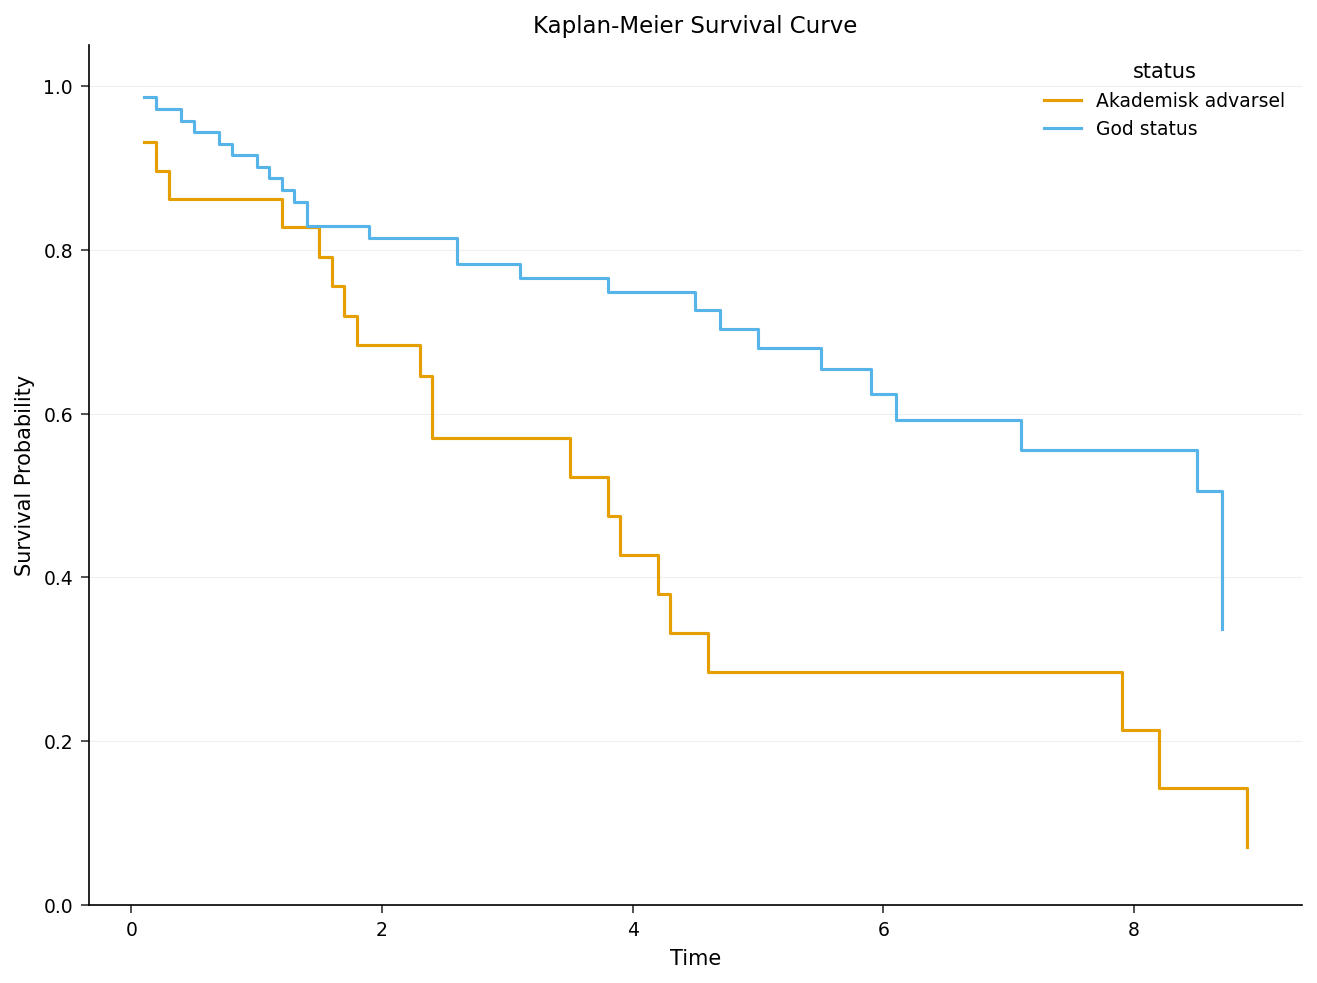

In [5]:
PROCEDURE LIFETEST data=indskrivninger PLOTS=SURVIVAL METHOD=km;
    TIME tid_semestre*frafaldet(0);
    STRATA status / TEST=(logrank WILCOXON);
KØR;

## 6. Multivariabel Cox proportional-hazard-model for frafald

**PROC PHREG** tilpasser **Cox proportional-hazard**-modellen for frafaldsrisikoen og justerer prædiktorerne samtidigt. Vigtige anmodninger:

- `frafaldet(0)` gør **frafald** til hændelsen og alt andet censureret.
- `CLASS foerste_gen_tekst (ref="Fortsættende generation") / param=ref` referencekoder faktoren for første generation, så dens hazard ratio læses mod studerende af fortsættende generation.
- `TIES=EFRON` er den anbefalede tilnærmelse til håndtering af sammenfald, når flere studerende forlader studiet i samme semester.
- `RL` tilføjer hazard ratio-konfidensintervaller (risikogrænser).
- `HAZARDRATIO`-sætningen rapporterer kontrasten for første generation mod referencegruppen.

En hazard ratio over 1 betyder *hurtigere* frafald (højere risiko); under 1 betyder *langsommere* frafald (beskyttende).

In [6]:
PROCEDURE PHREG data=indskrivninger;
    KLASSE foerste_gen_tekst (REF="Fortsættende generation") / PARAM=REF;
    MODEL tid_semestre*frafaldet(0) = gym_snit sem1_snit foerste_gen_tekst pell
          / TIES=efron rl;
    hazardratio "Første generation vs. fortsættende" foerste_gen_tekst / DIFF=REF;
KØR;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                                 Analysis of Maximum Likelihood Estimates                                                 

Parameter                                   DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
------------------------------------  --------  --------  --------------  ----------  ----------  ------------  -----------


NOTE: PROC PHREG data=indskrivninger

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Fortolkning og næste skridt

**Læsning af output, fra ende til anden:**

- **PROC MEANS** bekræfter det simulerede signal: studerende, der dimitterede, bærer en højere første-semester-GPA (2.94 mod 2.54) og high school-GPA (3.10 mod 2.90) end studerende, der faldt fra, og de stadig indskrevne studerende ligger på 12-semester-loftet — den højrecensurering, som overlevelsesmodellerne respekterer.
- **PROC FREQ** viser, at det akademiske advarselsflag i første semester følger udfaldet (21 af 29 markerede studerende faldt fra; 41 af 71 studerende med god status dimitterede; *p* = 0.0100), samtidig med at det ærligt fremhæver, at chi-i-anden er skrøbelig i en tabel med 100 studerende og tyndt besatte celler.
- **PROC UNIVARIATE** viser, at *betinget af frafald* forlader begge grupper studiet tidligt (median ~2.4–2.6 semestre); statuseffekten handler om, hvor mange studerende der falder fra, og hvor hurtigt risikopuljen tyndes ud, ikke om timingen blandt dem, der forlader studiet.
- **PROC LIFETEST** leverer overskriften: Kaplan-Meier-frafaldskurver, der adskiller sig skarpt efter status (median 3.8 mod 8.7 semestre; log-rank *p* = 0.0011, Wilcoxon *p* = 0.0056). Det tidlige varselsflag er en ægte, statistisk understøttet diskriminator af frafaldstiming.
- **PROC PHREG** kvantificerer hver prædiktors justerede effekt på frafaldsrisikoen. Efter justering er **første-semester-GPA den stærkeste beskyttende faktor** (hazard ratio 0.21 pr. GPA-point, 95% CI 0.10–0.44, *p* < 0.0001): hvert ekstra GPA-point skærer frafaldsrisikoen ned med omtrent fire femtedele. **High school-GPA** er også beskyttende (HR 0.45, 95% CI 0.22–0.91, *p* = 0.027). **Studerende af første generation** står over for omtrent dobbelt så høj frafaldsrisiko som jævnaldrende af fortsættende generation med samme GPA'er (HR 2.03, 95% CI 1.07–3.84, *p* = 0.031). **Pell-status er ikke signifikant**, når der kontrolleres for GPA (HR 0.95, 95% CI 0.53–1.69, *p* = 0.85) — en nyttig påmindelse om, at en rå risikofaktor kan forsvinde efter justering. Den globale nulhypotese afvises kategorisk (likelihood ratio chi-i-anden = 31.11 på 4 df, *p* < 0.0001).

**Hvordan en institution ville handle på dette.** Cox-modellen producerer en lineær prædiktor pr. studerende (risikoscore), der rangordner kohorten efter frafaldsrisiko; de studerende med højest risiko — lav første-semester-GPA kombineret med status som første generation — dirigeres til tidlig varslingsvejledning i deres første semestre, hvor indsatsen er billigst og mest effektiv. Kaplan-Meier-sammenligningen giver vejledere ét enkelt, forsvarligt kriterium, som de allerede indsamler ved udgangen af første semester: akademisk status.

**Forbehold og udvidelser.** (1) Denne syntetiske kohorte behandler dimission som censurering for frafaldsmodellen; med rigtige data er dimission og frafald ægte **konkurrerende risici**, og en udvidelse med konkurrerende risici (kumulativ incidens) via PROC PHREG `EVENTCODE=` ville undgå at overvurdere frafaldssandsynligheden. (2) Antagelsen om proportional hazard bør efterprøves (PHREG `ASSESS PH` eller Schoenfeld-residualer), før man stoler på en enkelt hazard ratio på tværs af alle semestre. (3) Tidsvarierende kovariater — semester-for-semester-GPA, ændringer i økonomisk støtte, kursusbelastning — er almindelige i fastholdelsesdata og håndteres naturligt af PHREG-programmeringssætninger. (4) Kohorten på 100 studerende her er dimensioneret til den ulicenserede kørselsgrænse; en produktionsanalyse ville omfatte flere tusinde studerende og stramme hvert konfidensinterval. Validér altid en implementeret risikoscore på en tilbageholdt kohorte, før du handler på den operationelt.